# Praktikum: Data Cleaning — Pima Indians Diabetes Dataset

Notebook ini mendemonstrasikan teknik-teknik data cleaning dari materi `Data-Cleaning.md`,
diterapkan pada dataset **Pima Indians Diabetes** (768 baris, 9 kolom).

Dataset berisi data medis pasien perempuan keturunan Pima Indian, dengan target `Outcome` (0 = non-diabetic, 1 = diabetic).

## 1. Import Library dan Load Data

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # suppress warnings agar output lebih bersih

In [2]:
df = pd.read_csv("diabetes.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Overview Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Observasi**:
- Nilai **minimum = 0** pada kolom Glucose, BloodPressure, SkinThickness, Insulin, dan BMI
- Secara medis, nilai 0 pada kolom-kolom tersebut tidak mungkin — ini adalah **disguised missing values**

## 3. Disguised Missing Values

Beberapa kolom menggunakan **0 sebagai placeholder** untuk missing data.
Affected columns: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`.

In [5]:
# Kolom yang seharusnya tidak bernilai 0
cols_zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Hitung jumlah 0 per kolom
zero_counts = (df[cols_zero_invalid] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(1)

pd.DataFrame({"Jumlah Nol": zero_counts, "Persentase (%)": zero_pct})

,Jumlah Nol,Persentase (%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


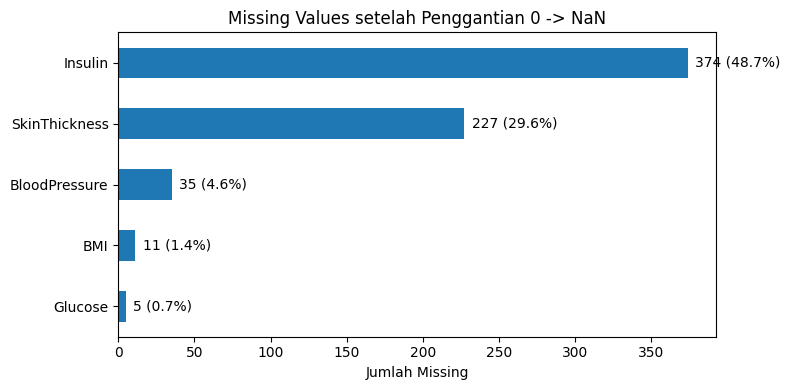

In [6]:
# Ganti 0 dengan NaN pada kolom yang tidak valid
df[cols_zero_invalid] = df[cols_zero_invalid].replace(0, np.nan)

# Visualisasi missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
missing.plot.barh(ax=ax)
ax.set_xlabel("Jumlah Missing")
ax.set_title("Missing Values setelah Penggantian 0 -> NaN")
for i, v in enumerate(missing):
    ax.text(v + 5, i, f"{v} ({v/len(df)*100:.1f}%)", va="center")
plt.tight_layout()
plt.show()

**Observasi**:
- **Insulin** paling banyak missing: 374 (48.7%) — hampir separuh data!
- **SkinThickness** juga cukup tinggi: 227 (29.6%)
- **Glucose** dan **BMI** relatif sedikit (0.7% dan 1.4%)

> **Penting**: Kolom dengan >40% missing values (seperti Insulin) perlu extra caution saat imputasi — hasilnya bisa heavily biased.

## 4. Imputasi Missing Values

Menggunakan **median** karena distribusi beberapa kolom sangat skewed (terutama Insulin).

> **Tips**: Median lebih robust dibanding mean untuk data skewed — tidak terpengaruh extreme values.

In [7]:
# Simpan copy sebelum imputasi untuk perbandingan nanti
df_before_impute = df.copy()

# Imputasi dengan median
for col in cols_zero_invalid:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col:20s} -> median = {median_val:.1f}, diisi {n_missing} nilai")

print(f"\nTotal missing setelah imputasi: {df.isnull().sum().sum()}")

Glucose              -> median = 117.0, diisi 5 nilai
BloodPressure        -> median = 72.0, diisi 35 nilai
SkinThickness        -> median = 29.0, diisi 227 nilai
Insulin              -> median = 125.0, diisi 374 nilai
BMI                  -> median = 32.3, diisi 11 nilai

Total missing setelah imputasi: 0


## 5. Deteksi Outlier

Demonstrasi tiga metode pada kolom **Insulin** — dipilih karena distribusinya sangat skewed dan memiliki banyak disguised missing values.

### 5.1 Metode IQR

In [8]:
col = "Insulin"
data = df[col]

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outliers_iqr = data[(data < batas_bawah) | (data > batas_atas)]

print(f"Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}")
print(f"Batas bawah = {batas_bawah:.1f}, Batas atas = {batas_atas:.1f}")
print(f"Jumlah outlier (IQR): {len(outliers_iqr)} dari {len(data)} data ({len(outliers_iqr)/len(data)*100:.1f}%)")

Q1 = 121.5, Q3 = 127.2, IQR = 5.8
Batas bawah = 112.9, Batas atas = 135.9
Jumlah outlier (IQR): 346 dari 768 data (45.1%)


> **Penting**: 45.1% outlier terlihat sangat tinggi — tapi ini bukan berarti hampir separuh data benar-benar outlier.
>
> Penyebabnya: **median imputation** di step sebelumnya mengisi 374 missing values (48.7%) dengan nilai median 125.0, sehingga distribusi Insulin menjadi sangat concentrated di sekitar 125.0 dan IQR menyempit drastis (hanya 5.8). Akibatnya, batas IQR sangat ketat dan banyak data asli terdeteksi sebagai outlier.
>
> **Takeaway**: Urutan langkah cleaning sangat berpengaruh terhadap hasil deteksi — order of operations matters!

### 5.2 Z-Score

In [9]:
z_scores = stats.zscore(data)
outliers_z = data[np.abs(z_scores) > 3]

print(f"Jumlah outlier (|z| > 3): {len(outliers_z)} dari {len(data)} data ({len(outliers_z)/len(data)*100:.1f}%)")
print(f"Nilai outlier: {sorted(outliers_z.values)}")

Jumlah outlier (|z| > 3): 20 dari 768 data (2.6%)
Nilai outlier: [np.float64(402.0), np.float64(415.0), np.float64(440.0), np.float64(465.0), np.float64(474.0), np.float64(478.0), np.float64(480.0), np.float64(480.0), np.float64(485.0), np.float64(495.0), np.float64(495.0), np.float64(510.0), np.float64(540.0), np.float64(543.0), np.float64(545.0), np.float64(579.0), np.float64(600.0), np.float64(680.0), np.float64(744.0), np.float64(846.0)]


### 5.3 Modified Z-Score (MAD)

In [10]:
median_val = data.median()
mad = np.median(np.abs(data - median_val))
modified_z = 0.6745 * (data - median_val) / mad

outliers_mz = data[np.abs(modified_z) > 3.5]

print(f"Median = {median_val:.1f}, MAD = {mad:.1f}")
print(f"Jumlah outlier (|Mz| > 3.5): {len(outliers_mz)} dari {len(data)} data ({len(outliers_mz)/len(data)*100:.1f}%)")

Median = 125.0, MAD = 3.0
Jumlah outlier (|Mz| > 3.5): 330 dari 768 data (43.0%)


### 5.4 Perbandingan Metode Deteksi

In [11]:
# Tabel perbandingan deteksi outlier pada beberapa kolom
detection_cols = ["Insulin", "BMI", "BloodPressure", "Age"]
results = []

for col in detection_cols:
    d = df[col]

    # IQR
    q1, q3 = d.quantile(0.25), d.quantile(0.75)
    iqr = q3 - q1
    n_iqr = ((d < q1 - 1.5*iqr) | (d > q3 + 1.5*iqr)).sum()

    # Z-score
    z = stats.zscore(d)
    n_z = (np.abs(z) > 3).sum()

    # Modified Z-score
    med = d.median()
    mad_val = np.median(np.abs(d - med))
    if mad_val == 0:
        n_mz = 0
    else:
        mz = 0.6745 * (d - med) / mad_val
        n_mz = (np.abs(mz) > 3.5).sum()

    results.append({"Kolom": col, "IQR": n_iqr, "Z-Score": n_z, "Modified Z-Score": n_mz})

pd.DataFrame(results).set_index("Kolom")

,IQR,Z-Score,Modified Z-Score
Kolom,,,
Insulin,346,20,330
BMI,8,5,3
BloodPressure,14,8,5
Age,9,5,13


**Observasi**:
- **Insulin**: IQR mendeteksi 346 outlier, Modified Z-Score 330, tapi Z-Score hanya 20
- Z-Score menggunakan **mean dan standard deviation** yang sangat sensitif terhadap extreme values — pada data skewed, mean dan std sudah "tertarik" oleh outlier itu sendiri (*under-detection*)
- IQR dan Modified Z-Score berbasis **median/quartile** yang lebih robust

> **Takeaway**: Untuk data skewed, gunakan IQR atau Modified Z-Score — Z-Score cenderung under-detect outlier.

## 6. Visualisasi Outlier

### 6.1 Boxplot semua kolom numerik

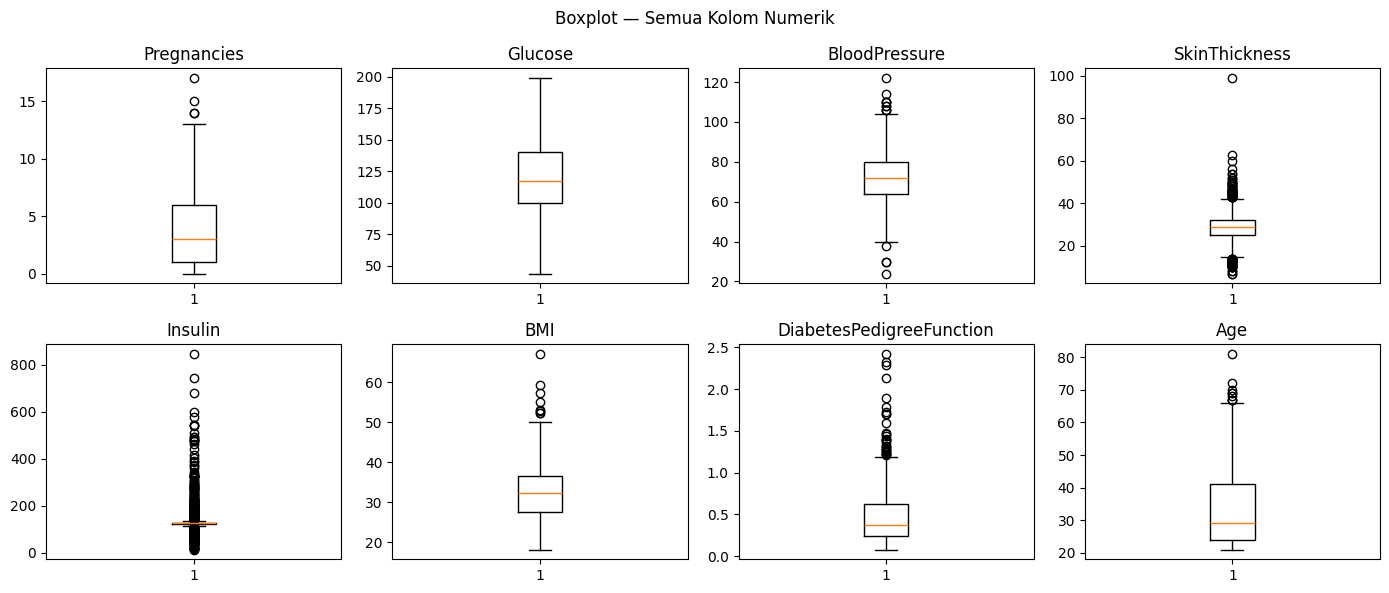

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("Outcome")

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

plt.suptitle("Boxplot — Semua Kolom Numerik")
plt.tight_layout()
plt.show()

**Observasi**:
- **Insulin** memiliki outlier paling banyak dan range terlebar
- **BloodPressure** dan **BMI** terlihat relatif simetris
- **Age** dan **Pregnancies** right-skewed (banyak pasien muda / sedikit kehamilan)

### 6.2 Histogram Insulin

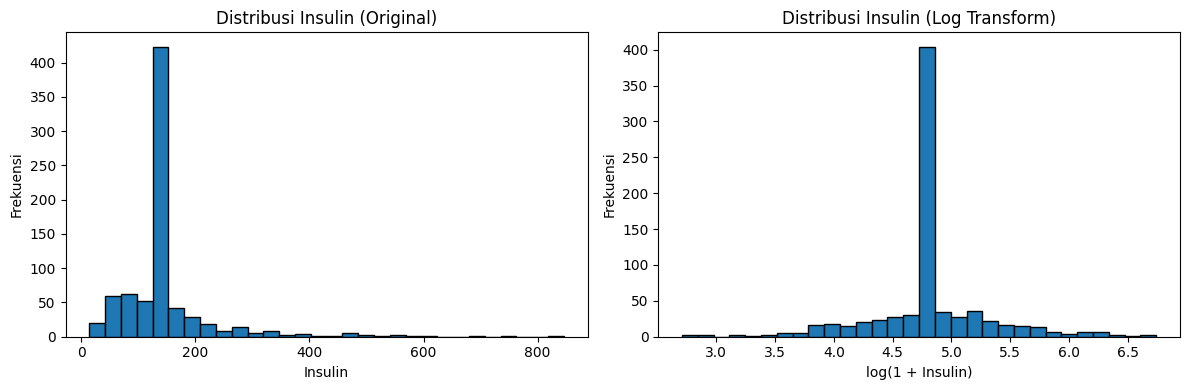

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Insulin"], bins=30, edgecolor="black")
axes[0].set_title("Distribusi Insulin (Original)")
axes[0].set_xlabel("Insulin")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(np.log1p(df["Insulin"]), bins=30, edgecolor="black")
axes[1].set_title("Distribusi Insulin (Log Transform)")
axes[1].set_xlabel("log(1 + Insulin)")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

**Observasi**:
- Distribusi **original** (kiri) sangat right-skewed — ada spike besar di sekitar 125 (efek median imputation)
- Setelah **log transform** (kanan), distribusi menjadi lebih simetris — tapi spike tetap terlihat

### 6.3 Scatter Plot

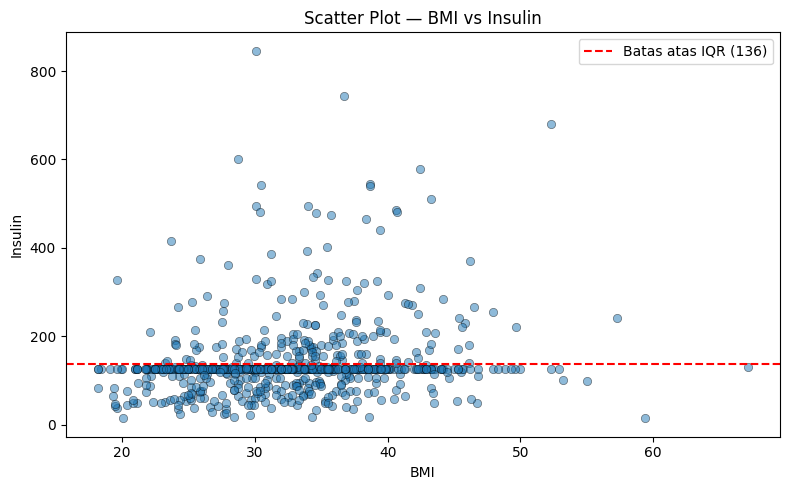

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["BMI"], df["Insulin"], alpha=0.5, edgecolors="black", linewidth=0.5)
ax.set_xlabel("BMI")
ax.set_ylabel("Insulin")
ax.set_title("Scatter Plot — BMI vs Insulin")

# Tambahkan garis batas IQR untuk Insulin
q1_ins, q3_ins = df["Insulin"].quantile(0.25), df["Insulin"].quantile(0.75)
iqr_ins = q3_ins - q1_ins
batas_atas_ins = q3_ins + 1.5 * iqr_ins
ax.axhline(y=batas_atas_ins, color="red", linestyle="--", label=f"Batas atas IQR ({batas_atas_ins:.0f})")
ax.legend()

plt.tight_layout()
plt.show()

**Observasi**:
- Terlihat **horizontal band** di sekitar Insulin = 125 — ini adalah imputed values (median)
- Data points di atas garis merah (batas IQR) terdeteksi sebagai outlier
- Tidak terlihat strong linear relationship antara BMI dan Insulin

## 7. Binning dan Smoothing

Demonstrasi pada kolom **Age** — membagi usia pasien ke dalam kelompok (bins) untuk noise reduction.

### 7.1 Equal-Width vs Equal-Frequency Binning

In [15]:
# Equal-width binning (3 bin)
df["Age_EqualWidth"] = pd.cut(df["Age"], bins=3)
print("=== Equal-Width Binning (3 bin) ===")
print(df["Age_EqualWidth"].value_counts().sort_index())

print()

# Equal-frequency binning (3 bin)
df["Age_EqualFreq"] = pd.qcut(df["Age"], q=3)
print("=== Equal-Frequency Binning (3 bin) ===")
print(df["Age_EqualFreq"].value_counts().sort_index())

=== Equal-Width Binning (3 bin) ===
Age_EqualWidth
(20.94, 41.0]    596
(41.0, 61.0]     147
(61.0, 81.0]      25
Name: count, dtype: int64

=== Equal-Frequency Binning (3 bin) ===
Age_EqualFreq
(20.999, 25.0]    267
(25.0, 36.0]      247
(36.0, 81.0]      254
Name: count, dtype: int64


### 7.2 Demonstrasi Smoothing

In [16]:
# Ambil sample 15 data untuk demo smoothing
sample = df["Age"].head(15).reset_index(drop=True)
print(f"Data asli (15 sample): {sample.values.tolist()}")

# Equal-frequency binning manual (depth = 5)
bin_size = 5
bins = [sample.iloc[i:i+bin_size] for i in range(0, len(sample), bin_size)]

print("\n=== Smoothing by Bin Means ===")
smoothed_means = []
for i, b in enumerate(bins):
    mean_val = round(b.mean(), 1)
    smoothed = [mean_val] * len(b)
    smoothed_means.extend(smoothed)
    print(f"  Bin {i+1}: {b.values.tolist()} -> {smoothed}")

print("\n=== Smoothing by Bin Medians ===")
for i, b in enumerate(bins):
    med_val = round(b.median(), 1)
    smoothed = [med_val] * len(b)
    print(f"  Bin {i+1}: {b.values.tolist()} -> {smoothed}")

print("\n=== Smoothing by Bin Boundaries ===")
for i, b in enumerate(bins):
    lo, hi = b.min(), b.max()
    smoothed = [lo if abs(v - lo) <= abs(v - hi) else hi for v in b]
    print(f"  Bin {i+1}: {b.values.tolist()} -> {smoothed}")

Data asli (15 sample): [50, 31, 32, 21, 33, 30, 26, 29, 53, 54, 30, 34, 57, 59, 51]

=== Smoothing by Bin Means ===
  Bin 1: [50, 31, 32, 21, 33] -> [np.float64(33.4), np.float64(33.4), np.float64(33.4), np.float64(33.4), np.float64(33.4)]
  Bin 2: [30, 26, 29, 53, 54] -> [np.float64(38.4), np.float64(38.4), np.float64(38.4), np.float64(38.4), np.float64(38.4)]
  Bin 3: [30, 34, 57, 59, 51] -> [np.float64(46.2), np.float64(46.2), np.float64(46.2), np.float64(46.2), np.float64(46.2)]

=== Smoothing by Bin Medians ===
  Bin 1: [50, 31, 32, 21, 33] -> [np.float64(32.0), np.float64(32.0), np.float64(32.0), np.float64(32.0), np.float64(32.0)]
  Bin 2: [30, 26, 29, 53, 54] -> [np.float64(30.0), np.float64(30.0), np.float64(30.0), np.float64(30.0), np.float64(30.0)]
  Bin 3: [30, 34, 57, 59, 51] -> [np.float64(51.0), np.float64(51.0), np.float64(51.0), np.float64(51.0), np.float64(51.0)]

=== Smoothing by Bin Boundaries ===
  Bin 1: [50, 31, 32, 21, 33] -> [np.int64(50), np.int64(21), np.int6

## 8. Handling Outlier

Demonstrasi pada kolom **Insulin** yang memiliki banyak outlier dan distribusi right-skewed.

### 8.1 Capping (Winsorization)

In [17]:
Q1 = df["Insulin"].quantile(0.25)
Q3 = df["Insulin"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

df["Insulin_Capped"] = df["Insulin"].clip(lower=batas_bawah, upper=batas_atas)

print(f"Batas bawah: {batas_bawah:.1f}, Batas atas: {batas_atas:.1f}")
print(f"Sebelum — min: {df['Insulin'].min():.1f}, max: {df['Insulin'].max():.1f}")
print(f"Sesudah — min: {df['Insulin_Capped'].min():.1f}, max: {df['Insulin_Capped'].max():.1f}")
print(f"Nilai yang di-cap: {(df['Insulin'] != df['Insulin_Capped']).sum()}")

Batas bawah: 112.9, Batas atas: 135.9
Sebelum — min: 14.0, max: 846.0
Sesudah — min: 112.9, max: 135.9
Nilai yang di-cap: 346


### 8.2 Trimming

In [18]:
mask_outlier = (df["Insulin"] < batas_bawah) | (df["Insulin"] > batas_atas)
df_trimmed = df[~mask_outlier]

print(f"Sebelum trimming: {len(df)} baris")
print(f"Sesudah trimming: {len(df_trimmed)} baris")
print(f"Data yang dihapus: {mask_outlier.sum()} baris ({mask_outlier.sum()/len(df)*100:.1f}%)")

Sebelum trimming: 768 baris
Sesudah trimming: 422 baris
Data yang dihapus: 346 baris (45.1%)


> **Penting**: Trimming menghapus 346 baris (45.1%) — terlalu agresif!
>
> Proporsi yang acceptable untuk trimming biasanya di bawah 5-10%. Jika outlier terlalu banyak seperti kasus ini, pertimbangkan **capping** atau **transformasi**.
>
> Ingat: banyaknya "outlier" di sini sebagian besar karena efek median imputation yang menyempitkan IQR (lihat Section 5.1).

### 8.3 Transformasi (Log, Sqrt, Box-Cox)

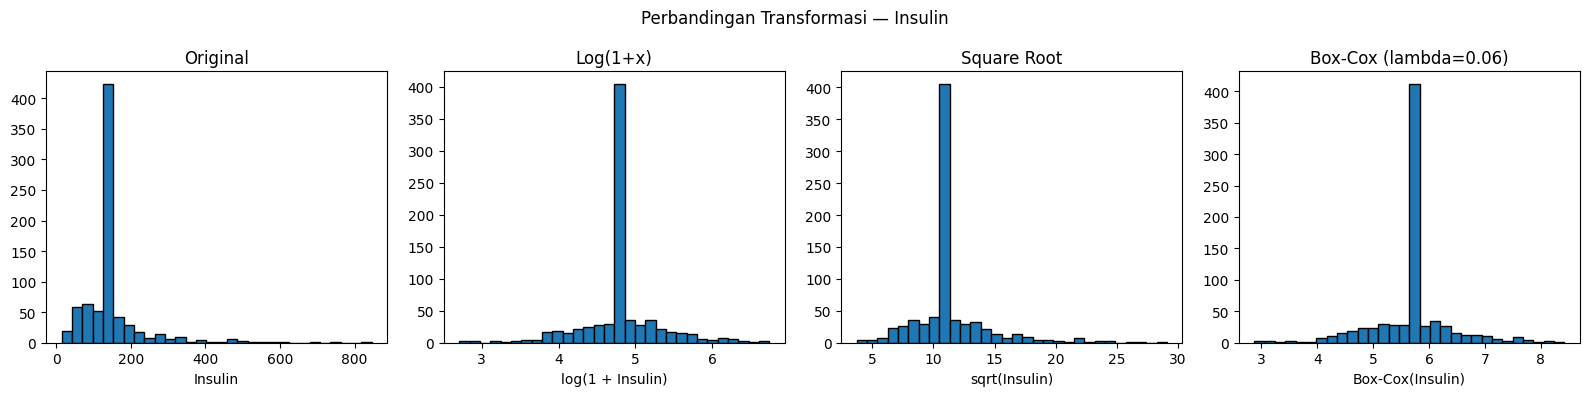

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].hist(df["Insulin"], bins=30, edgecolor="black")
axes[0].set_title("Original")
axes[0].set_xlabel("Insulin")

# Log transform
axes[1].hist(np.log1p(df["Insulin"]), bins=30, edgecolor="black")
axes[1].set_title("Log(1+x)")
axes[1].set_xlabel("log(1 + Insulin)")

# Sqrt transform
axes[2].hist(np.sqrt(df["Insulin"]), bins=30, edgecolor="black")
axes[2].set_title("Square Root")
axes[2].set_xlabel("sqrt(Insulin)")

# Box-Cox transform
data_positive = df["Insulin"][df["Insulin"] > 0]
data_boxcox, lmbda = boxcox(data_positive)
axes[3].hist(data_boxcox, bins=30, edgecolor="black")
axes[3].set_title(f"Box-Cox (lambda={lmbda:.2f})")
axes[3].set_xlabel("Box-Cox(Insulin)")

plt.suptitle("Perbandingan Transformasi — Insulin")
plt.tight_layout()
plt.show()

**Observasi**:
- **Log(1+x)** dan **Square Root** masing-masing mengurangi skewness, tapi spike dari imputed values tetap visible
- **Box-Cox** memberikan distribusi paling mendekati normal — lambda otomatis dihitung oleh scipy

> **Tips**: Box-Cox hanya bisa digunakan untuk data positif. Untuk data dengan nilai 0 atau negatif, gunakan Yeo-Johnson transform.

### 8.4 Perbandingan: Capping vs Trimming

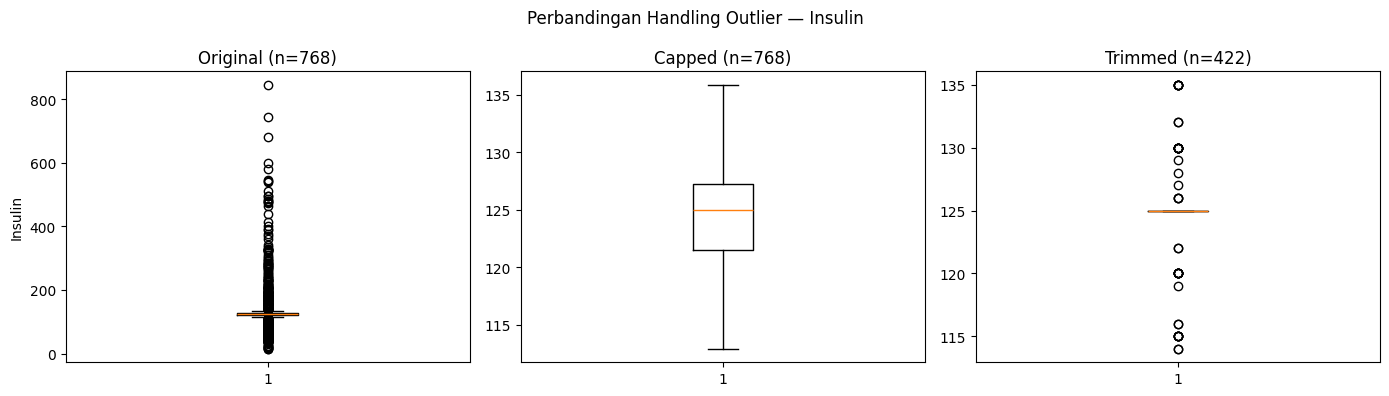

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].boxplot(df["Insulin"], vert=True)
axes[0].set_title(f"Original (n={len(df)})")
axes[0].set_ylabel("Insulin")

axes[1].boxplot(df["Insulin_Capped"], vert=True)
axes[1].set_title(f"Capped (n={len(df)})")

axes[2].boxplot(df_trimmed["Insulin"], vert=True)
axes[2].set_title(f"Trimmed (n={len(df_trimmed)})")

plt.suptitle("Perbandingan Handling Outlier — Insulin")
plt.tight_layout()
plt.show()

**Observasi**:
- **Original**: banyak outlier (titik-titik di atas whisker)
- **Capped** (n=768): outlier di-clip ke batas IQR — jumlah data tetap sama
- **Trimmed** (n=422): outlier dihapus — data berkurang drastis (45.1% hilang)

> **Takeaway**: Capping lebih aman untuk preserving sample size. Trimming hanya cocok jika proporsi outlier kecil (<5-10%).

## 9. Dampak Cleaning pada Statistik Deskriptif

Bandingkan statistik before dan after capping pada kolom Insulin.

In [21]:
stats_before = df["Insulin"].describe()
stats_after = df["Insulin_Capped"].describe()

comparison = pd.DataFrame({
    "Sebelum": stats_before,
    "Sesudah (Capping)": stats_after,
    "Perubahan (%)": ((stats_after - stats_before) / stats_before * 100).round(1)
})
comparison

,Sebelum,Sesudah (Capping),Perubahan (%)
count,768.000000,768.000000,0.0
mean,140.671875,124.691081,-11.4
std,86.383060,7.913595,-90.8
min,14.000000,112.875000,706.2
25%,121.500000,121.500000,0.0
50%,125.000000,125.000000,0.0
75%,127.250000,127.250000,0.0
max,846.000000,135.875000,-83.9


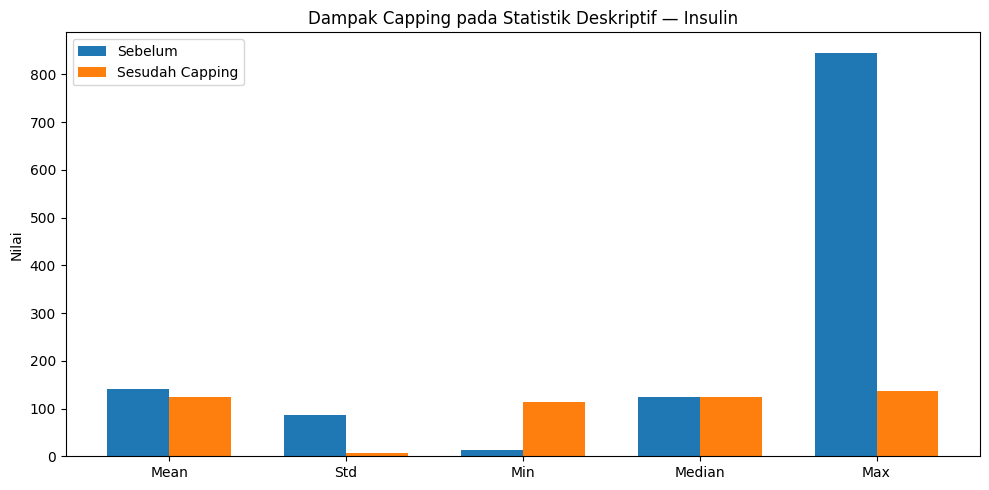

In [22]:
# Visualisasi dampak pada mean dan std
metrics = ["mean", "std", "min", "50%", "max"]
labels = ["Mean", "Std", "Min", "Median", "Max"]

before_vals = [stats_before[m] for m in metrics]
after_vals = [stats_after[m] for m in metrics]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, before_vals, width, label="Sebelum")
ax.bar(x + width/2, after_vals, width, label="Sesudah Capping")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Nilai")
ax.set_title("Dampak Capping pada Statistik Deskriptif — Insulin")
ax.legend()
plt.tight_layout()
plt.show()

**Observasi**:
- **Mean** turun 11.4% setelah capping — extreme values tidak lagi inflate mean
- **Std** turun drastis 90.8% — variabilitas sangat berkurang
- **Median** tetap sama (0% change) — robust terhadap outlier handling
- **Max** turun 83.9% dari 846 ke 135.9 (batas atas IQR)

---

## 10. Ringkasan

Apa yang sudah kita pelajari di notebook ini:

| Topik | Key Takeaway |
|---|---|
| Disguised Missing Values | Nilai 0 sebagai placeholder — cek domain knowledge sebelum replace |
| Imputasi | Median lebih robust dibanding mean untuk data skewed |
| Deteksi Outlier | IQR dan Modified Z-Score lebih reliable untuk skewed data dibanding Z-Score |
| Order of Operations | Urutan cleaning steps sangat berpengaruh — imputasi sebelum deteksi bisa bias hasilnya |
| Visualisasi | Boxplot, histogram, scatter plot — selalu visualisasi before dan after cleaning |
| Handling Outlier | Capping preserves sample size, trimming untuk outlier sedikit (<5-10%), transformasi untuk normalisasi distribusi |
| Dampak Cleaning | Mean dan std berubah signifikan, median tetap stabil |

### Workflow Data Cleaning

```
Raw Data → Identifikasi Missing/Disguised Values → Imputasi → Deteksi Outlier → Visualisasi → Handling (Capping/Trimming/Transform) → Validasi Dampak
```

Untuk referensi lengkap, baca `Data-Cleaning.md` — terutama bagian decision framework dan 6 dimensi kualitas data.

In [23]:
# Cleanup: drop temporary columns yang dibuat selama praktikum
df_final = df.drop(columns=["Age_EqualWidth", "Age_EqualFreq", "Insulin_Capped"])
print(f"Dataset final: {df_final.shape}")
df_final.describe()

Dataset final: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000
